# Minimal Falkon Systematics Example

This notebook implements the 1D nuisance-ratio example directly, without importing `nplm_systematics`. It contains only the pieces needed to understand the method:

1. generate central and nuisance-varied samples;
2. train one Falkon log-ratio model for every nuisance value;
3. fit the Taylor coefficients from the model predictions;
4. inspect $E_{0.2}$ and $E_{0.3}$ separately;
5. reconstruct the hybrid approximation.

The final model is

$$
\widehat{\log r}(x;\nu)
=\nu\,\widehat\delta_1^L(x)
+\frac{\nu^2}{2}\widehat\delta_2^Q(x).
$$

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from falkon import LogisticFalkon
from falkon.gsc_losses import WeightedCrossEntropyLoss
from falkon.kernels import GaussianKernel
from falkon.options import FalkonOptions

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})

/data/marcol/anaconda3/envs/flk_torch113_cu116/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

The linear and quadratic fits use different symmetric nuisance points. Their union determines how many Falkon models are trained. Change the arrays below to test other choices.

In [2]:
seed = 123
rng = np.random.default_rng(seed)

n_central = 20_000
n_varied = 20_000

linear_nu_values = np.array([-0.1, -0.05, 0.05, 0.1])
quadratic_nu_values = np.array([-0.30, -0.05, 0.05, 0.30])
# Train one model for every value needed by either Taylor fit.
training_nu_values = np.unique(np.concatenate([
    linear_nu_values, quadratic_nu_values
]))

sigma = 2.0
nystrom_centers = 40_000
penalty = 1e-6
iterations = 100_000
cg_tolerance = np.sqrt(1e-7)
use_cpu = False
keops = "yes"

# This limits evaluation and plotting only; generated samples are unbounded.
x_max = 6.0
x_grid = np.linspace(0.0, x_max, 250).reshape(-1, 1)

print("models to train:", training_nu_values)

models to train: [-0.3  -0.1  -0.05  0.05  0.1   0.3 ]


## 2. Define the Toy Model

The central distribution is exponential with unit scale. A scale nuisance changes the scale to $e^\nu$. The exact log-ratio and Taylor coefficients are known, so this is a useful closure test.

In [3]:
def sample_exponential(n_events, nu, random_generator):
    """Draw events from the nuisance-varied exponential distribution."""
    scale = np.exp(float(nu))
    return random_generator.exponential(scale=scale, size=(n_events, 1))


def exact_log_ratio(x, nu):
    """Evaluate the exact log p(x|nu) / p(x|0)."""
    x = np.asarray(x).reshape(-1)
    nu = float(nu)
    return x * (1.0 - np.exp(-nu)) - nu


def exact_delta1(x):
    """Evaluate the exact first Taylor coefficient."""
    return np.asarray(x).reshape(-1) - 1.0


def exact_delta2(x):
    """Evaluate the exact second Taylor coefficient."""
    return -np.asarray(x).reshape(-1)

## 3. Generate the Training Samples

The reference sample is generated once and reused in every fit. Each nuisance value gets its own independently generated varied sample.

In [4]:
# Reuse one central sample in every nuisance-point fit.
x_central = sample_exponential(n_central, 0.0, rng)
varied_samples = {
    float(nu): sample_exponential(n_varied, nu, rng)
    for nu in training_nu_values
}

print("central shape:", x_central.shape)
print("varied shapes:", {nu: x.shape for nu, x in varied_samples.items()})

central shape: (20000, 1)
varied shapes: {-0.3: (20000, 1), -0.1: (20000, 1), -0.05: (20000, 1), 0.05: (20000, 1), 0.1: (20000, 1), 0.3: (20000, 1)}


## 4. Define the Falkon Ratio Fit

The classifier receives label 0 for central events and label 1 for varied events. `neg_weight = n_varied / n_central` removes the class-count prior, so the fitted score estimates $\log[p(x\mid\nu)/p(x\mid0)]$.

In [5]:
def fit_log_ratio(x_reference, x_varied):
    """Train one Falkon model for log p_varied / p_reference."""
    n_reference = x_reference.shape[0]
    n_variation = x_varied.shape[0]
    # Remove the binary classifier's finite sample-count prior.
    neg_weight = n_variation / n_reference

    kernel = GaussianKernel(sigma)
    options = FalkonOptions(
        cg_tolerance=cg_tolerance,
        keops_active=keops,
        use_cpu=use_cpu,
        debug=False,
    )
    model = LogisticFalkon(
        kernel=kernel,
        M=nystrom_centers,
        penalty_list=[penalty],
        iter_list=[iterations],
        loss=WeightedCrossEntropyLoss(kernel, neg_weight=neg_weight),
        seed=seed,
        options=options,
    )

    # Stack the two distributions into one binary-classification sample.
    x_train = np.vstack([x_reference, x_varied])
    y_train = np.concatenate([
        np.zeros(n_reference),
        np.ones(n_variation),
    ]).reshape(-1, 1)

    model.fit(
        torch.from_numpy(np.ascontiguousarray(x_train, dtype=np.float64)),
        torch.from_numpy(np.ascontiguousarray(y_train, dtype=np.float64)),
    )
    return model


def predict_log_ratio(model, x):
    """Evaluate a fitted Falkon log-ratio model."""
    x = np.ascontiguousarray(x, dtype=np.float64)
    prediction = model.predict(torch.from_numpy(x))
    return prediction.detach().cpu().numpy().reshape(-1)

## 5. Train One Model per Nuisance Value

The dictionary key is the nuisance value and the dictionary value is the corresponding fitted Falkon model.

In [6]:
# Each model learns g_nu(x) = log[p(x|nu) / p(x|0)].
ratio_models = {}
for nu in training_nu_values:
    nu = float(nu)
    start = time.time()
    ratio_models[nu] = fit_log_ratio(x_central, varied_samples[nu])
    print(f"nu={nu:+.2f}: {time.time() - start:.1f} s")

Iteration 0 - penalty 1.000000e-06 - sub-iterations 100000
nu=-0.30: 129.3 s
Iteration 0 - penalty 1.000000e-06 - sub-iterations 100000
nu=-0.10: 117.6 s
Iteration 0 - penalty 1.000000e-06 - sub-iterations 100000
nu=-0.05: 118.1 s
Iteration 0 - penalty 1.000000e-06 - sub-iterations 100000
nu=+0.05: 119.3 s
Iteration 0 - penalty 1.000000e-06 - sub-iterations 100000
nu=+0.10: 119.3 s
Iteration 0 - penalty 1.000000e-06 - sub-iterations 100000
nu=+0.30: 122.7 s


## 6. Fit the Taylor Coefficients

Each trained model is first evaluated on the same `x_grid`. For a fixed grid point $x_j$, these predictions form a response vector

$$
\mathbf g(x_j)=\begin{pmatrix}\widehat g_{\nu_1}(x_j) & \cdots & \widehat g_{\nu_m}(x_j)\end{pmatrix}^T.
$$

For the linear fit, the design matrix has one column, $A_L=(\nu_i)$, and we solve

$$
\mathbf g(x_j)\simeq A_L\,\delta_1^L(x_j).
$$

For the quadratic fit, each row of the design matrix is

$$
A_{Q,i}=\begin{pmatrix}\nu_i & \nu_i^2/2\end{pmatrix},
$$

and we solve

$$
\mathbf g(x_j)\simeq A_Q
\begin{pmatrix}\delta_1^Q(x_j) \\ \delta_2^Q(x_j)\end{pmatrix}.
$$

There is no constant column because the density ratio satisfies $g(x;0)=0$. In the code, `response` has shape `(number of nuisance values, number of grid points)`. `np.linalg.lstsq` therefore performs the same fit for every grid point in one call and returns an array with shape `(order, number of grid points)`.

Finally, the hybrid model selects `linear_coefficients[0]` as $\widehat\delta_1^L$ and `quadratic_coefficients[1]` as $\widehat\delta_2^Q$. The quadratic fit also produces $\delta_1^Q$, but it is not used in the final reconstruction.

In [7]:
def fit_taylor_coefficients(predictions, nuisance_values, order):
    """Fit linear or quadratic coefficients without an intercept."""
    nuisance_values = np.asarray(nuisance_values, dtype=np.float64)
    response = np.vstack([
        predictions[float(nu)] for nu in nuisance_values
    ])

    # Rows are nuisance points; columns are Taylor basis functions.
    if order == 1:
        design = nuisance_values.reshape(-1, 1)
    elif order == 2:
        design = np.column_stack([
            nuisance_values,
            0.5 * nuisance_values**2,
        ])
    else:
        raise ValueError("order must be 1 or 2")

    # One solve fits the coefficients at every x-grid point.
    return np.linalg.lstsq(design, response, rcond=None)[0]


grid_predictions = {
    nu: predict_log_ratio(model, x_grid)
    for nu, model in ratio_models.items()
}

linear_coefficients = fit_taylor_coefficients(
    grid_predictions, linear_nu_values, order=1
)
quadratic_coefficients = fit_taylor_coefficients(
    grid_predictions, quadratic_nu_values, order=2
)

# Hybrid choice: small steps for delta1, larger steps for delta2.
delta1_learned = linear_coefficients[0]
delta2_learned = quadratic_coefficients[1]

## 7. Inspect $E_{0.2}$ and $E_{0.3}$

Each symmetric pair provides an independent finite-step estimate

$$
E_h(x)=\frac{\widehat g(x;+h)+\widehat g(x;-h)}{h^2}.
$$

h=0.1: E_h(0)=-1.4395, RMSE=53.0940
h=0.3: E_h(0)=+0.4419, RMSE=1.0174


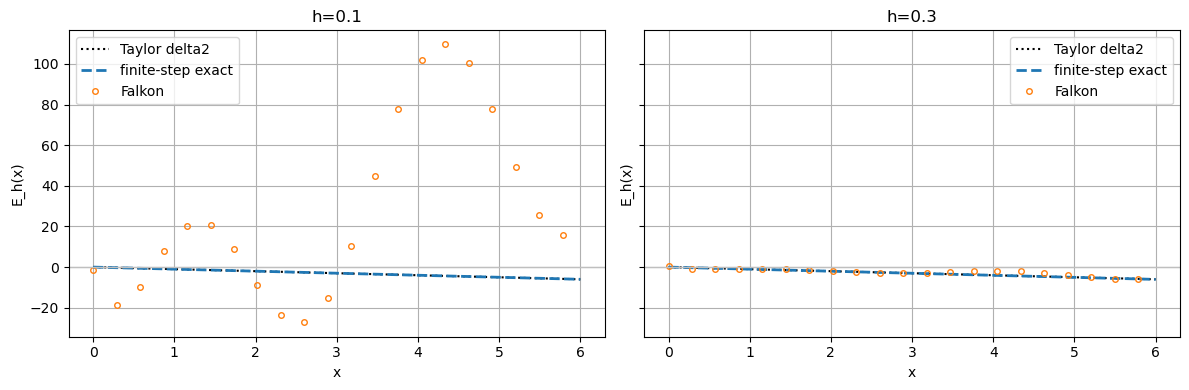

In [8]:
x_flat = x_grid.reshape(-1)
delta2_true = exact_delta2(x_flat)
quadratic_steps = np.unique(np.abs(quadratic_nu_values))

fig, axes = plt.subplots(1, len(quadratic_steps), figsize=(12, 4), sharey=True)
for ax, step in zip(np.atleast_1d(axes), quadratic_steps):
    step = float(step)
    # The odd linear contribution cancels in this symmetric sum.
    estimate = (
        grid_predictions[step] + grid_predictions[-step]
    ) / step**2
    finite_exact = (
        exact_log_ratio(x_flat, +step)
        + exact_log_ratio(x_flat, -step)
    ) / step**2

    print(
        f"h={step:.1f}: E_h(0)={estimate[0]:+.4f}, "
        f"RMSE={np.sqrt(np.mean((estimate - finite_exact)**2)):.4f}"
    )
    ax.plot(x_flat, delta2_true, ":", color="black", label="Taylor delta2")
    ax.plot(x_flat, finite_exact, "--", lw=2, label="finite-step exact")
    ax.plot(
        x_flat, estimate, "o", fillstyle="none",
        markevery=12, ms=4, label="Falkon"
    )
    ax.axhline(0.0, color="0.75", lw=1)
    ax.set_title(f"h={step:.1f}")
    ax.set_xlabel("x")
    ax.set_ylabel("E_h(x)")
    ax.legend()

fig.tight_layout();

## 8. Check the Hybrid Coefficients

The final approximation takes $\delta_1$ from the linear nuisance points and $\delta_2$ from the quadratic nuisance points.

delta1 RMSE: 0.45663860641406906
delta2 RMSE: 1.0382103785031218


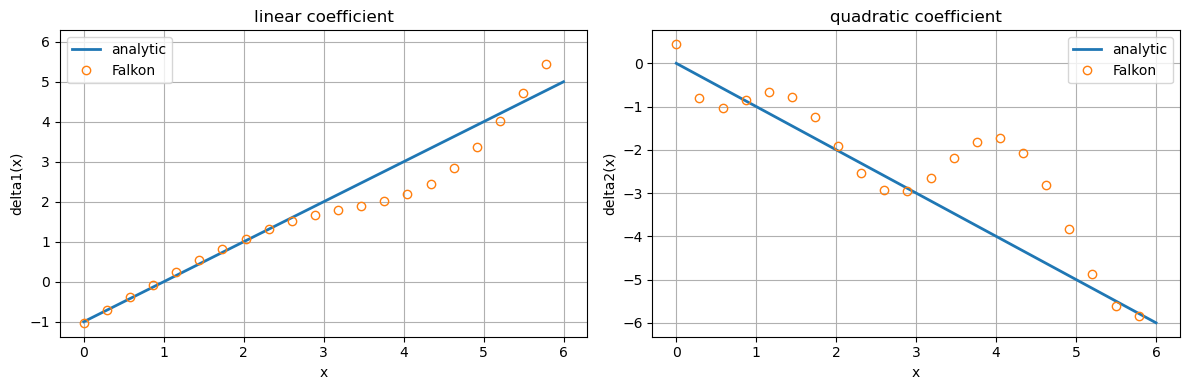

In [9]:
delta1_true = exact_delta1(x_flat)

print("delta1 RMSE:", np.sqrt(np.mean((delta1_learned - delta1_true)**2)))
print("delta2 RMSE:", np.sqrt(np.mean((delta2_learned - delta2_true)**2)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_flat, delta1_true, lw=2, label="analytic")
axes[0].plot(
    x_flat, delta1_learned, "o", fillstyle="none",
    markevery=12, label="Falkon"
)
axes[0].set_title("linear coefficient")
axes[0].set_xlabel("x")
axes[0].set_ylabel("delta1(x)")
axes[0].legend()

axes[1].plot(x_flat, delta2_true, lw=2, label="analytic")
axes[1].plot(
    x_flat, delta2_learned, "o", fillstyle="none",
    markevery=12, label="Falkon"
)
axes[1].set_title("quadratic coefficient")
axes[1].set_xlabel("x")
axes[1].set_ylabel("delta2(x)")
axes[1].legend()
fig.tight_layout();

## 9. Reconstruct the Log-Ratio

Because this notebook is intended for code inspection, the final check is pointwise and does not introduce histogram binning or caching.

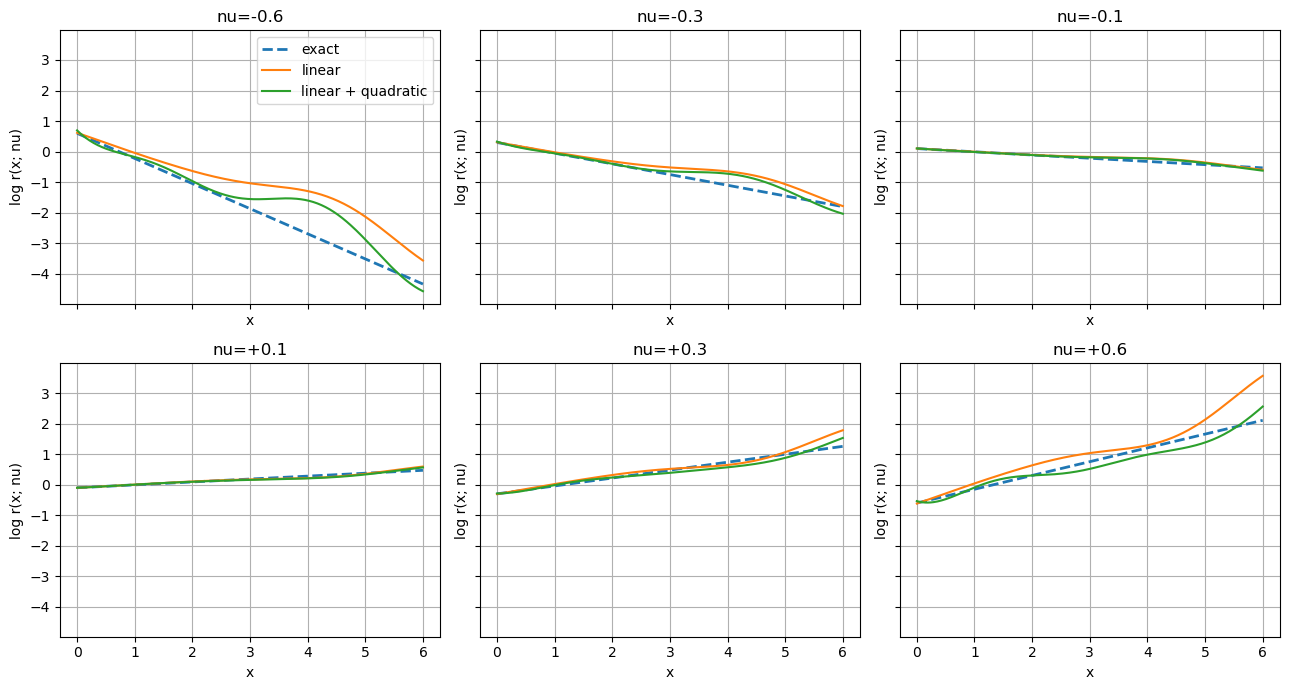

In [10]:
test_nu_values = [-0.6, -0.3, -0.1, 0.1, 0.3, 0.6]
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)

for ax, nu in zip(axes.reshape(-1), test_nu_values):
    exact = exact_log_ratio(x_flat, nu)
    linear = nu * delta1_learned
    # Both approximations share delta1; the hybrid additionally uses delta2.
    hybrid = linear + 0.5 * nu**2 * delta2_learned

    ax.plot(x_flat, exact, "--", lw=2, label="exact")
    ax.plot(x_flat, linear, lw=1.5, label="linear")
    ax.plot(x_flat, hybrid, lw=1.5, label="linear + quadratic")
    ax.set_title(f"nu={nu:+.1f}")
    ax.set_xlabel("x")
    ax.set_ylabel("log r(x; nu)")

axes[0, 0].legend()
fig.tight_layout();

## 10. Fig. 3 Analogue

For comparison with the paper, evaluate the learned coefficients on the central events and average the resulting event weights inside each bin. Dashed curves are the exact pointwise ratio, filled squares are the quartic bin-level monitor, and empty circles are the binned Falkon reconstruction.

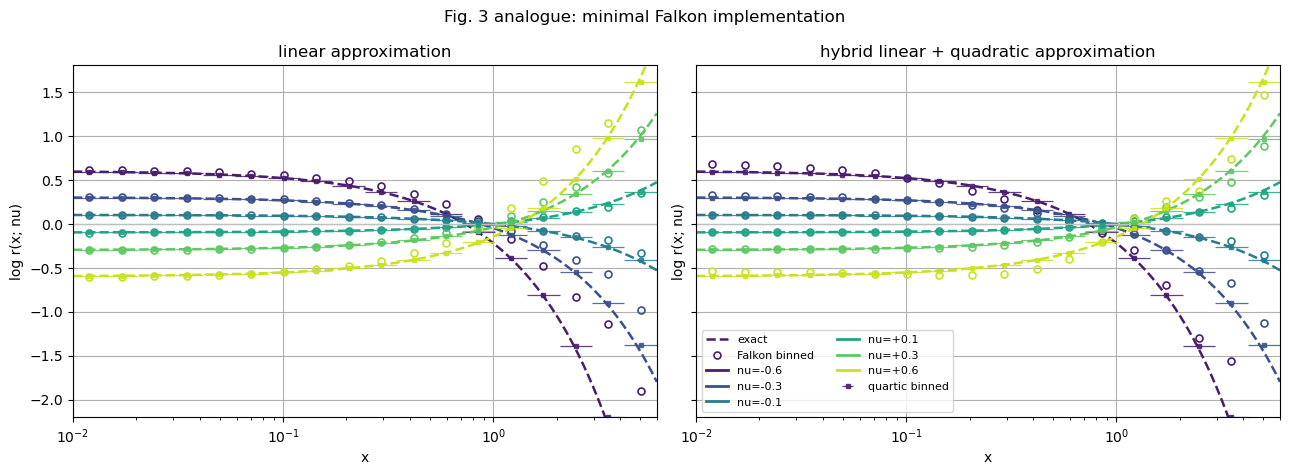

In [11]:
def exact_bin_log_ratio(bin_edges, nu):
    """Calculate log N_bin(nu) / N_bin(0) analytically."""
    low = np.asarray(bin_edges[:-1])
    high = np.asarray(bin_edges[1:])
    scale = np.exp(float(nu))
    varied_probability = np.exp(-low / scale) - np.exp(-high / scale)
    central_probability = np.exp(-low) - np.exp(-high)
    return np.log(varied_probability / central_probability)


def binned_learned_log_ratio(x_reference, log_ratio, bin_edges):
    """Average learned event weights inside each reference bin."""
    x_reference = np.asarray(x_reference).reshape(-1)
    event_weights = np.exp(np.asarray(log_ratio).reshape(-1))
    values = []
    for low, high in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (x_reference >= low) & (x_reference < high)
        values.append(
            np.log(np.mean(event_weights[in_bin])) if np.any(in_bin) else np.nan
        )
    return np.asarray(values)


def fit_quartic_bin_monitor(bin_edges, nuisance_scan):
    """Fit the analytic bin response as a quartic polynomial in nu."""
    bin_values = np.vstack([
        exact_bin_log_ratio(bin_edges, nu) for nu in nuisance_scan
    ])
    return [
        np.polyfit(nuisance_scan, bin_values[:, index], 4)
        for index in range(bin_values.shape[1])
    ]


central_predictions = {
    nu: predict_log_ratio(model, x_central)
    for nu, model in ratio_models.items()
}
delta1_central = fit_taylor_coefficients(
    central_predictions, linear_nu_values, order=1
)[0]
delta2_central = fit_taylor_coefficients(
    central_predictions, quadratic_nu_values, order=2
)[1]

figure3_nu_values = [-0.6, -0.3, -0.1, 0.1, 0.3, 0.6]
figure3_nu_scan = np.linspace(-0.6, 0.6, 49)
figure3_x_min = 1e-2
figure3_bin_edges = np.geomspace(figure3_x_min, x_max, 19)
figure3_bin_centers = np.sqrt(
    figure3_bin_edges[:-1] * figure3_bin_edges[1:]
)
figure3_bin_xerr = np.vstack([
    figure3_bin_centers - figure3_bin_edges[:-1],
    figure3_bin_edges[1:] - figure3_bin_centers,
])
figure3_x_dense = np.geomspace(figure3_x_min, x_max, 250)
quartic_coefficients = fit_quartic_bin_monitor(
    figure3_bin_edges, figure3_nu_scan
)
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(figure3_nu_values)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
x_reference = x_central.reshape(-1)

for index, (nu, color) in enumerate(zip(figure3_nu_values, colors)):
    exact = exact_log_ratio(figure3_x_dense, nu)
    linear_event_ratio = nu * delta1_central
    hybrid_event_ratio = (
        linear_event_ratio + 0.5 * nu**2 * delta2_central
    )
    linear_binned = binned_learned_log_ratio(
        x_reference, linear_event_ratio, figure3_bin_edges
    )
    hybrid_binned = binned_learned_log_ratio(
        x_reference, hybrid_event_ratio, figure3_bin_edges
    )
    quartic_binned = np.asarray([
        np.polyval(coefficient, nu) for coefficient in quartic_coefficients
    ])

    for ax, learned_binned in zip(axes, [linear_binned, hybrid_binned]):
        ax.plot(
            figure3_x_dense, exact, "--", color=color, lw=1.8,
            label="exact" if index == 0 else "_nolegend_"
        )
        ax.errorbar(
            figure3_bin_centers, quartic_binned, xerr=figure3_bin_xerr,
            fmt="s", color=color, ms=3.5, elinewidth=0.9, capsize=0,
            linestyle="none", alpha=0.85,
            label="quartic binned" if index == 0 else "_nolegend_",
        )
        ax.plot(
            figure3_bin_centers, learned_binned, "o", color=color,
            markerfacecolor="white", fillstyle="none", ms=5, mew=1.2,
            label="Falkon binned" if index == 0 else "_nolegend_",
        )

axes[0].set_title("linear approximation")
axes[1].set_title("hybrid linear + quadratic approximation")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlim(figure3_x_min, x_max)
    ax.set_ylim(-2.2, 1.8)
    ax.set_xlabel("x")
    ax.set_ylabel("log r(x; nu)")
    ax.axhline(0.0, color="0.75", lw=1)

for nu, color in zip(figure3_nu_values, colors):
    axes[1].plot([], [], color=color, lw=2, label=f"nu={nu:+.1f}")
axes[1].legend(fontsize=8, ncol=2, loc="lower left")
fig.suptitle("Fig. 3 analogue: minimal Falkon implementation")
fig.tight_layout();